#Task 2. Speech Audio Denoising Using a Pretrained Model

Use a pretrained speech denoising model to remove background noise from speech recordings. The model should be used for inference only; training or fine-tuning a new denoising model is not required.

###Tasks

- Load noisy speech samples from the selected dataset.

- Use a pretrained denoising model such as DTLN.

- Run inference to generate denoised speech.

- Compare the noisy and denoised audio using waveforms and spectrograms.

- Save the denoised audio files.

###Visual Output

- Noisy and denoised spectrograms.

- Waveform comparison before and after denoising.



In [1]:
#import req libs
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

In [12]:
audio_path = "/content/noisy_speech.wav"

noisy_audio, sr = librosa.load(
    audio_path,
    sr=None
)

print("Sample Rate :", sr)

print("Number of Samples :", len(noisy_audio))

print("Duration :", len(noisy_audio)/sr, "seconds")

Sample Rate : 48000
Number of Samples : 299838
Duration : 6.246625 seconds


In [21]:
import os

os.makedirs("input_audio", exist_ok=True)
os.makedirs("output_audio", exist_ok=True)

## DTLN Speech Denoising

The pretrained DTLN (Dual-Signal Transformation LSTM Network) model is used to remove background noise from the noisy speech recording. The model is used only for inference, and no additional training or fine-tuning is performed. The noisy speech is passed through the pretrained model to generate a cleaner speech signal.

In [26]:
!python run_evaluation.py \
-i input_audio \
-o output_audio \
-m pretrained_model/model.h5

2026-08-02 13:22:45.305178: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ [(None, None,     │          0 │ input_layer[0][0] │
│                     │ 257), (None,      │            │                   │
│                     │ None, 257)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (No

In [28]:
denoised_path = "/content/DTLN/output_audio/noisy_speech.wav"

denoised_audio, denoised_sr = librosa.load(
    denoised_path,
    sr=None
)

print("Sample Rate :", denoised_sr)
print("Duration :", len(denoised_audio)/denoised_sr)

Sample Rate : 16000
Duration : 6.246625


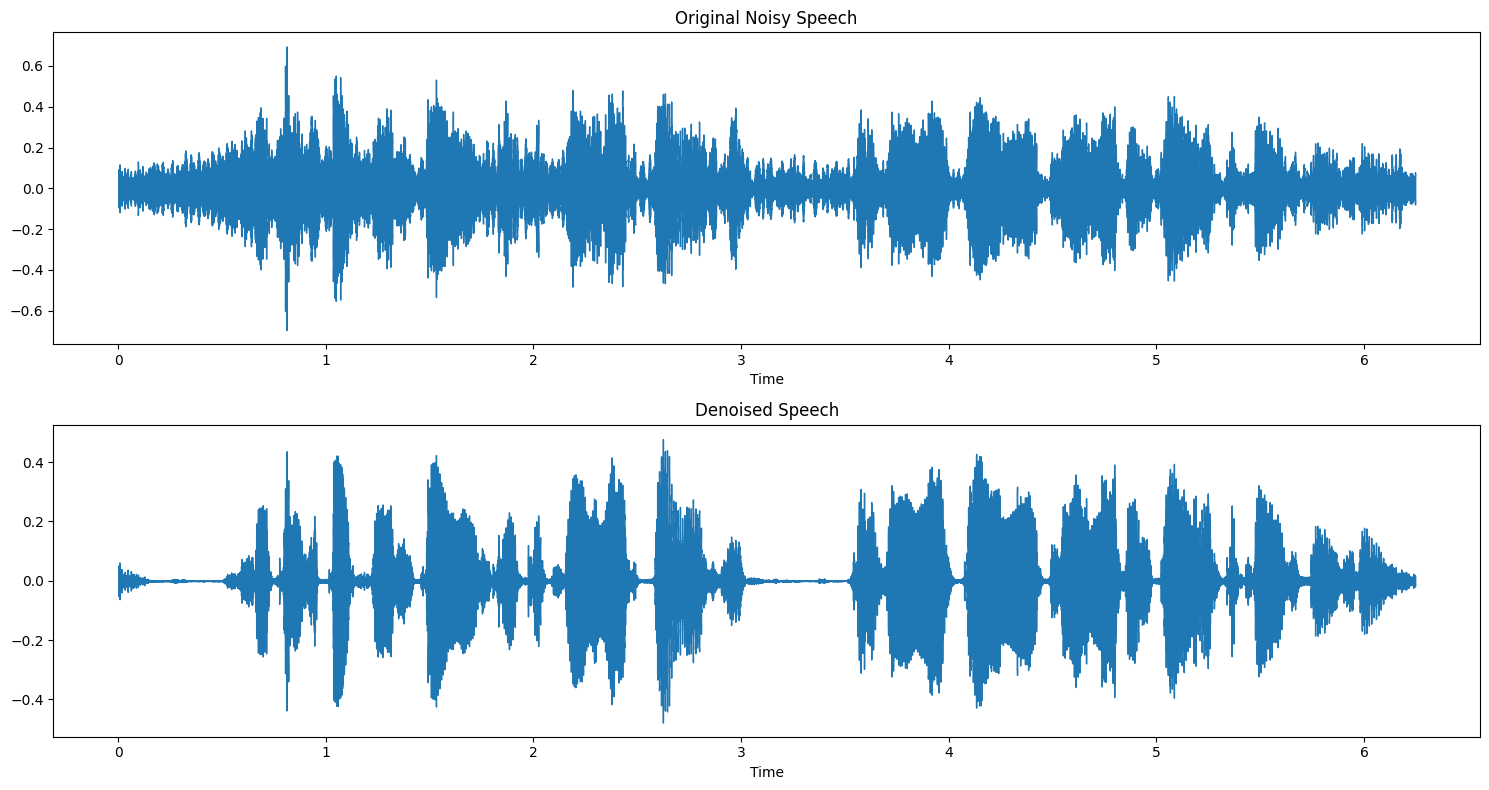

In [29]:
plt.figure(figsize=(15,8))

plt.subplot(2,1,1)

librosa.display.waveshow(
    noisy_audio,
    sr=sr
)

plt.title("Original Noisy Speech")

plt.subplot(2,1,2)

librosa.display.waveshow(
    denoised_audio,
    sr=denoised_sr
)

plt.title("Denoised Speech")

plt.tight_layout()

plt.show()

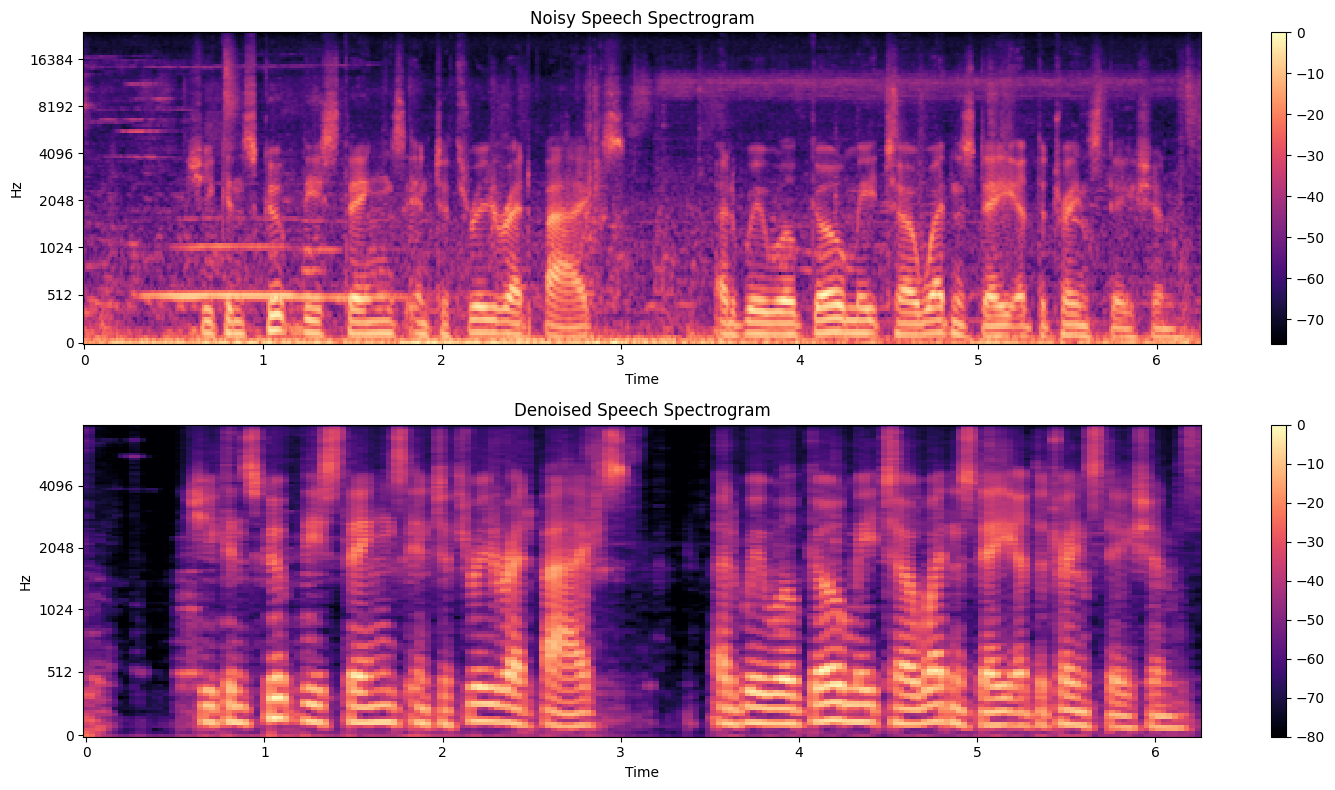

In [30]:
noisy_spec = librosa.feature.melspectrogram(
    y=noisy_audio,
    sr=sr
)

denoised_spec = librosa.feature.melspectrogram(
    y=denoised_audio,
    sr=denoised_sr
)

plt.figure(figsize=(15,8))

plt.subplot(2,1,1)

librosa.display.specshow(
    librosa.power_to_db(noisy_spec, ref=np.max),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.title("Noisy Speech Spectrogram")

plt.colorbar()

plt.subplot(2,1,2)

librosa.display.specshow(
    librosa.power_to_db(denoised_spec, ref=np.max),
    sr=denoised_sr,
    x_axis="time",
    y_axis="mel"
)

plt.title("Denoised Speech Spectrogram")

plt.colorbar()

plt.tight_layout()

plt.show()

## Final Observation

The pretrained DTLN (Dual-Signal Transformation LSTM Network) successfully reduced background noise from the noisy speech recording.

The waveform comparison shows changes in the speech signal after denoising, while the Mel spectrogram demonstrates reduced background noise energy and clearer speech components.

The denoised speech was generated successfully using the pretrained model without performing any additional training or fine-tuning. This demonstrates the effectiveness of pretrained deep learning models for speech enhancement tasks.